In [2]:
# Celda 1 — Imports y carga de datos procesados
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, classification_report, 
                             confusion_matrix, roc_curve)

plt.style.use('seaborn-v0_8')

# Cargar datos procesados
X_train = np.load('../data/X_train.npy')
X_test  = np.load('../data/X_test.npy')
y_train = np.load('../data/y_train.npy')
y_test  = np.load('../data/y_test.npy')

print(f"✅ Datos cargados")
print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")

✅ Datos cargados
X_train: (5754, 15)
X_test:  (848, 15)


In [3]:
# Celda 2 — Entrenar modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
import time

modelos = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                 SVC(probability=True, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

resultados = {}

for nombre, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train, y_train)
    tiempo = round(time.time() - inicio, 2)
    y_pred_proba = modelo.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_pred_proba)
    resultados[nombre] = {'AUC-ROC': round(auc, 4), 'Tiempo(s)': tiempo}
    print(f"✅ {nombre:25} AUC-ROC: {auc:.4f}  ({tiempo}s)")

print("\n🏆 Entrenamiento completado")

✅ Logistic Regression       AUC-ROC: 0.6962  (0.27s)
✅ Random Forest             AUC-ROC: 0.6387  (1.05s)
✅ SVM                       AUC-ROC: 0.6542  (7.04s)
✅ XGBoost                   AUC-ROC: 0.5729  (0.86s)

🏆 Entrenamiento completado


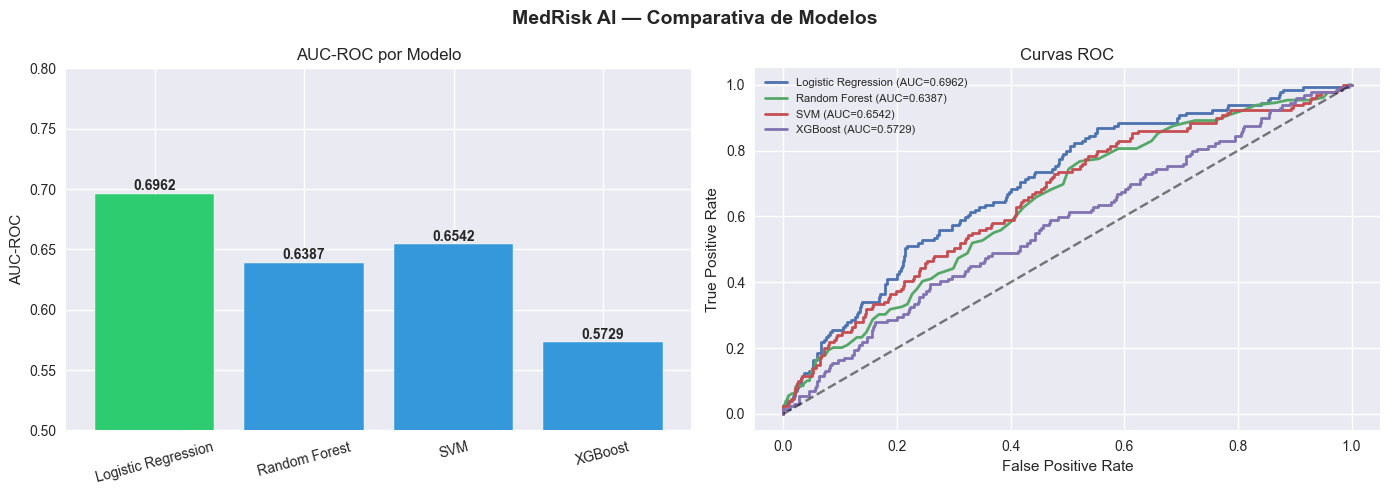

✅ Gráfico guardado en reports/


In [4]:
# Celda 3 — Comparativa visual y curvas ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('MedRisk AI — Comparativa de Modelos', fontsize=14, fontweight='bold')

# Gráfico 1 — AUC-ROC por modelo
nombres = list(resultados.keys())
aucs = [resultados[n]['AUC-ROC'] for n in nombres]
colores = ['#2ecc71' if a == max(aucs) else '#3498db' for a in aucs]

bars = axes[0].bar(nombres, aucs, color=colores, edgecolor='white')
axes[0].set_ylim(0.5, 0.8)
axes[0].set_title('AUC-ROC por Modelo')
axes[0].set_ylabel('AUC-ROC')
axes[0].tick_params(axis='x', rotation=15)
for bar, auc in zip(bars, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
                f'{auc:.4f}', ha='center', fontsize=10, fontweight='bold')

# Gráfico 2 — Curvas ROC
for nombre, modelo in modelos.items():
    y_pred_proba = modelo.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = resultados[nombre]['AUC-ROC']
    axes[1].plot(fpr, tpr, label=f'{nombre} (AUC={auc})', linewidth=2)

axes[1].plot([0,1], [0,1], 'k--', alpha=0.5)
axes[1].set_title('Curvas ROC')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../reports/comparativa_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico guardado en reports/")

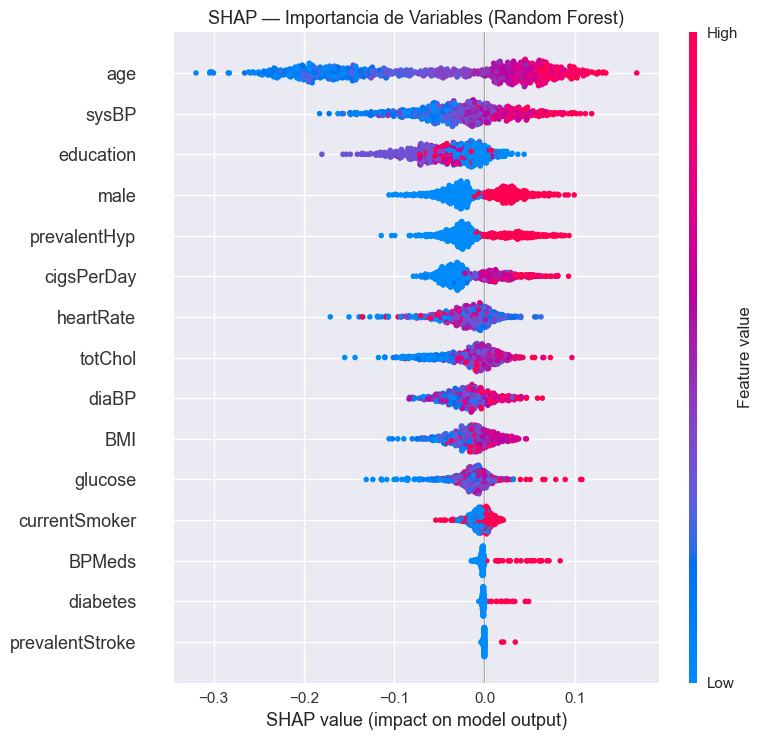

✅ SHAP guardado en reports/


In [5]:
# Celda 4 — SHAP explicabilidad con Random Forest
import shap

feature_names = ['male','age','education','currentSmoker','cigsPerDay',
                 'BPMeds','prevalentStroke','prevalentHyp','diabetes',
                 'totChol','sysBP','diaBP','BMI','heartRate','glucose']

rf_model = modelos['Random Forest']
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:,:,1], X_test, 
                  feature_names=feature_names, 
                  show=False)
plt.title('SHAP — Importancia de Variables (Random Forest)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP guardado en reports/")

In [6]:
# Celda 5 — Conclusiones
print("""
=== CONCLUSIONES MODELOS ML ===

1. MEJOR MODELO: Logistic Regression (AUC-ROC: 0.6962)
   - Sorprendente pero común en datasets médicos pequeños
   - Las relaciones lineales capturan bien el riesgo

2. RANKING:
   1. Logistic Regression  → 0.6962
   2. SVM                  → 0.6542
   3. Random Forest        → 0.6387
   4. XGBoost              → 0.5729

3. SHAP — Variables más importantes:
   1. age        → mayor edad = mayor riesgo
   2. sysBP      → presión sistólica alta = mayor riesgo
   3. education  → nivel educativo como proxy socioeconómico
   4. male       → hombres con mayor riesgo
   5. prevalentHyp → hipertensión preexistente

4. PRÓXIMO PASO: Análisis de supervivencia (R)
""")


=== CONCLUSIONES MODELOS ML ===

1. MEJOR MODELO: Logistic Regression (AUC-ROC: 0.6962)
   - Sorprendente pero común en datasets médicos pequeños
   - Las relaciones lineales capturan bien el riesgo

2. RANKING:
   1. Logistic Regression  → 0.6962
   2. SVM                  → 0.6542
   3. Random Forest        → 0.6387
   4. XGBoost              → 0.5729

3. SHAP — Variables más importantes:
   1. age        → mayor edad = mayor riesgo
   2. sysBP      → presión sistólica alta = mayor riesgo
   3. education  → nivel educativo como proxy socioeconómico
   4. male       → hombres con mayor riesgo
   5. prevalentHyp → hipertensión preexistente

4. PRÓXIMO PASO: Análisis de supervivencia (R)

